## 1. Import Semua Packages/Library yang Digunakan

Persiapan awal dengan mengimpor seluruh library dasar, pengolahan data, visualisasi, hingga Keras/TensorFlow untuk pembuatan model *Deep Learning*. Bagian ini juga memuat konfigurasi API Kaggle untuk mengunduh dataset secara langsung.

In [2]:
# Library dasar
import os
import shutil
import random
from pathlib import Path
from google.colab import userdata

# Library pengolahan data & visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.image as mpimg

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

# Cek versi TensorFlow dan ketersediaan GPU
print("TensorFlow Version:", tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# Mengambil kredensial API Token dari fitur Secrets Colab
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Memastikan library Kaggle terinstal di sistem
!pip install -q kaggle
print('Kaggle API siap!')

TensorFlow Version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Kaggle API siap!


## 2. Download dan Ekstraksi Dataset dari Kaggle

Mengunduh dataset **RAF-DB Face Emotion Dataset** secara langsung menggunakan Kaggle CLI dan mengekstraknya ke direktori kerja `/content/dataset`. Langkah ini juga dilengkapi dengan pengecekan direktori untuk memahami struktur folder hasil ekstraksi.

In [3]:
# Slug dataset dari Kaggle untuk RAF-DB Face Emotion
DATASET_SLUG = 'nishchalchandel/raf-db-face-emotion-dataset'
EXTRACT_DIR  = '/content/dataset'

# Path folder training asal
TRAIN_SRC    = os.path.join(EXTRACT_DIR, 'train')

# Proses unduh otomatis jika folder belum ada
if not os.path.exists(TRAIN_SRC):
    print('Mulai download dataset RAF-DB Face Emotion...')
    !kaggle datasets download -d {DATASET_SLUG} -p {EXTRACT_DIR} --unzip
    print('Download selesai!')
else:
    print('Dataset sudah ada, skip download.')

print("\n--- Struktur Folder Hasil Ekstraksi ---")
# Menampilkan isi folder utama (maksimal kedalaman 2 tingkat) untuk melihat struktur setelag diekstrak
!find {EXTRACT_DIR} -maxdepth 2 -type d

Mulai download dataset RAF-DB Face Emotion...
Dataset URL: https://www.kaggle.com/datasets/nishchalchandel/raf-db-face-emotion-dataset
License(s): MIT
100% 37.6M/37.6M [00:03<00:00, 10.7MB/s]

Download selesai!

--- Struktur Folder Hasil Ekstraksi ---
/content/dataset
/content/dataset/test
/content/dataset/test/sad
/content/dataset/test/fear
/content/dataset/test/neutral
/content/dataset/test/disgust
/content/dataset/test/surprise
/content/dataset/test/happy
/content/dataset/test/angry
/content/dataset/train
/content/dataset/train/sad
/content/dataset/train/fear
/content/dataset/train/neutral
/content/dataset/train/disgust
/content/dataset/train/surprise
/content/dataset/train/happy
/content/dataset/train/angry
/content/dataset/validation
/content/dataset/validation/sad
/content/dataset/validation/fear
/content/dataset/validation/neutral
/content/dataset/validation/disgust
/content/dataset/validation/surprise
/content/dataset/validation/happy
/content/dataset/validation/angry


In [4]:
# 1. Konfigurasi Ukuran & Folder Dasar
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

BASE_DIR  = '/content/dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'validation')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
bagian_data = ['train', 'validation', 'test']

# Tahap 1: Kumpulkan data dan hitung total keseluruhan
rekap_data = {}
total_semua_data = 0
classes = []

for split in bagian_data:
    split_path = os.path.join(BASE_DIR, split)
    if os.path.exists(split_path):
        classes = sorted(os.listdir(split_path))

        # Hitung gambar per kelas dan masukkan ke dalam dictionary
        counts = {cls: len(os.listdir(os.path.join(split_path, cls))) for cls in classes}
        total_split = sum(counts.values())

        rekap_data[split] = {'classes': classes, 'counts': counts, 'total': total_split}
        total_semua_data += total_split

In [5]:
# Tahap 2: Tampilkan hasil cetak beserta persentasenya
for split, data in rekap_data.items():
    print(f'=== DATA {split.upper()} ===')
    print(f'Total Kelas  : {len(data["classes"])}\n')
    for cls, jumlah in data['counts'].items():
        persen_kelas = (jumlah / data['total']) * 100 if data['total'] > 0 else 0
        print(f'  {cls:<15} : {jumlah:>5} gambar ({persen_kelas:.1f}%)')

    persen_split = (data['total'] / total_semua_data) * 100 if total_semua_data > 0 else 0
    print(f'\nTotal {split:<10} : {data["total"]} gambar ({persen_split:.1f}% dari keseluruhan)')
    print("-" * 55 + "\n")

print(f'TOTAL KESELURUHAN DATA: {total_semua_data} gambar (100%)\n')

=== DATA TRAIN ===
Total Kelas  : 7

  angry           :   705 gambar (5.7%)
  disgust         :   717 gambar (5.8%)
  fear            :   281 gambar (2.3%)
  happy           :  4772 gambar (38.9%)
  neutral         :  2524 gambar (20.6%)
  sad             :  1982 gambar (16.2%)
  surprise        :  1290 gambar (10.5%)

Total train      : 12271 gambar (80.0% dari keseluruhan)
-------------------------------------------------------

=== DATA VALIDATION ===
Total Kelas  : 7

  angry           :    81 gambar (5.3%)
  disgust         :    80 gambar (5.2%)
  fear            :    37 gambar (2.4%)
  happy           :   592 gambar (38.6%)
  neutral         :   340 gambar (22.2%)
  sad             :   239 gambar (15.6%)
  surprise        :   164 gambar (10.7%)

Total validation : 1533 gambar (10.0% dari keseluruhan)
-------------------------------------------------------

=== DATA TEST ===
Total Kelas  : 7

  angry           :    81 gambar (5.3%)
  disgust         :    80 gambar (5.2%)
  fear  

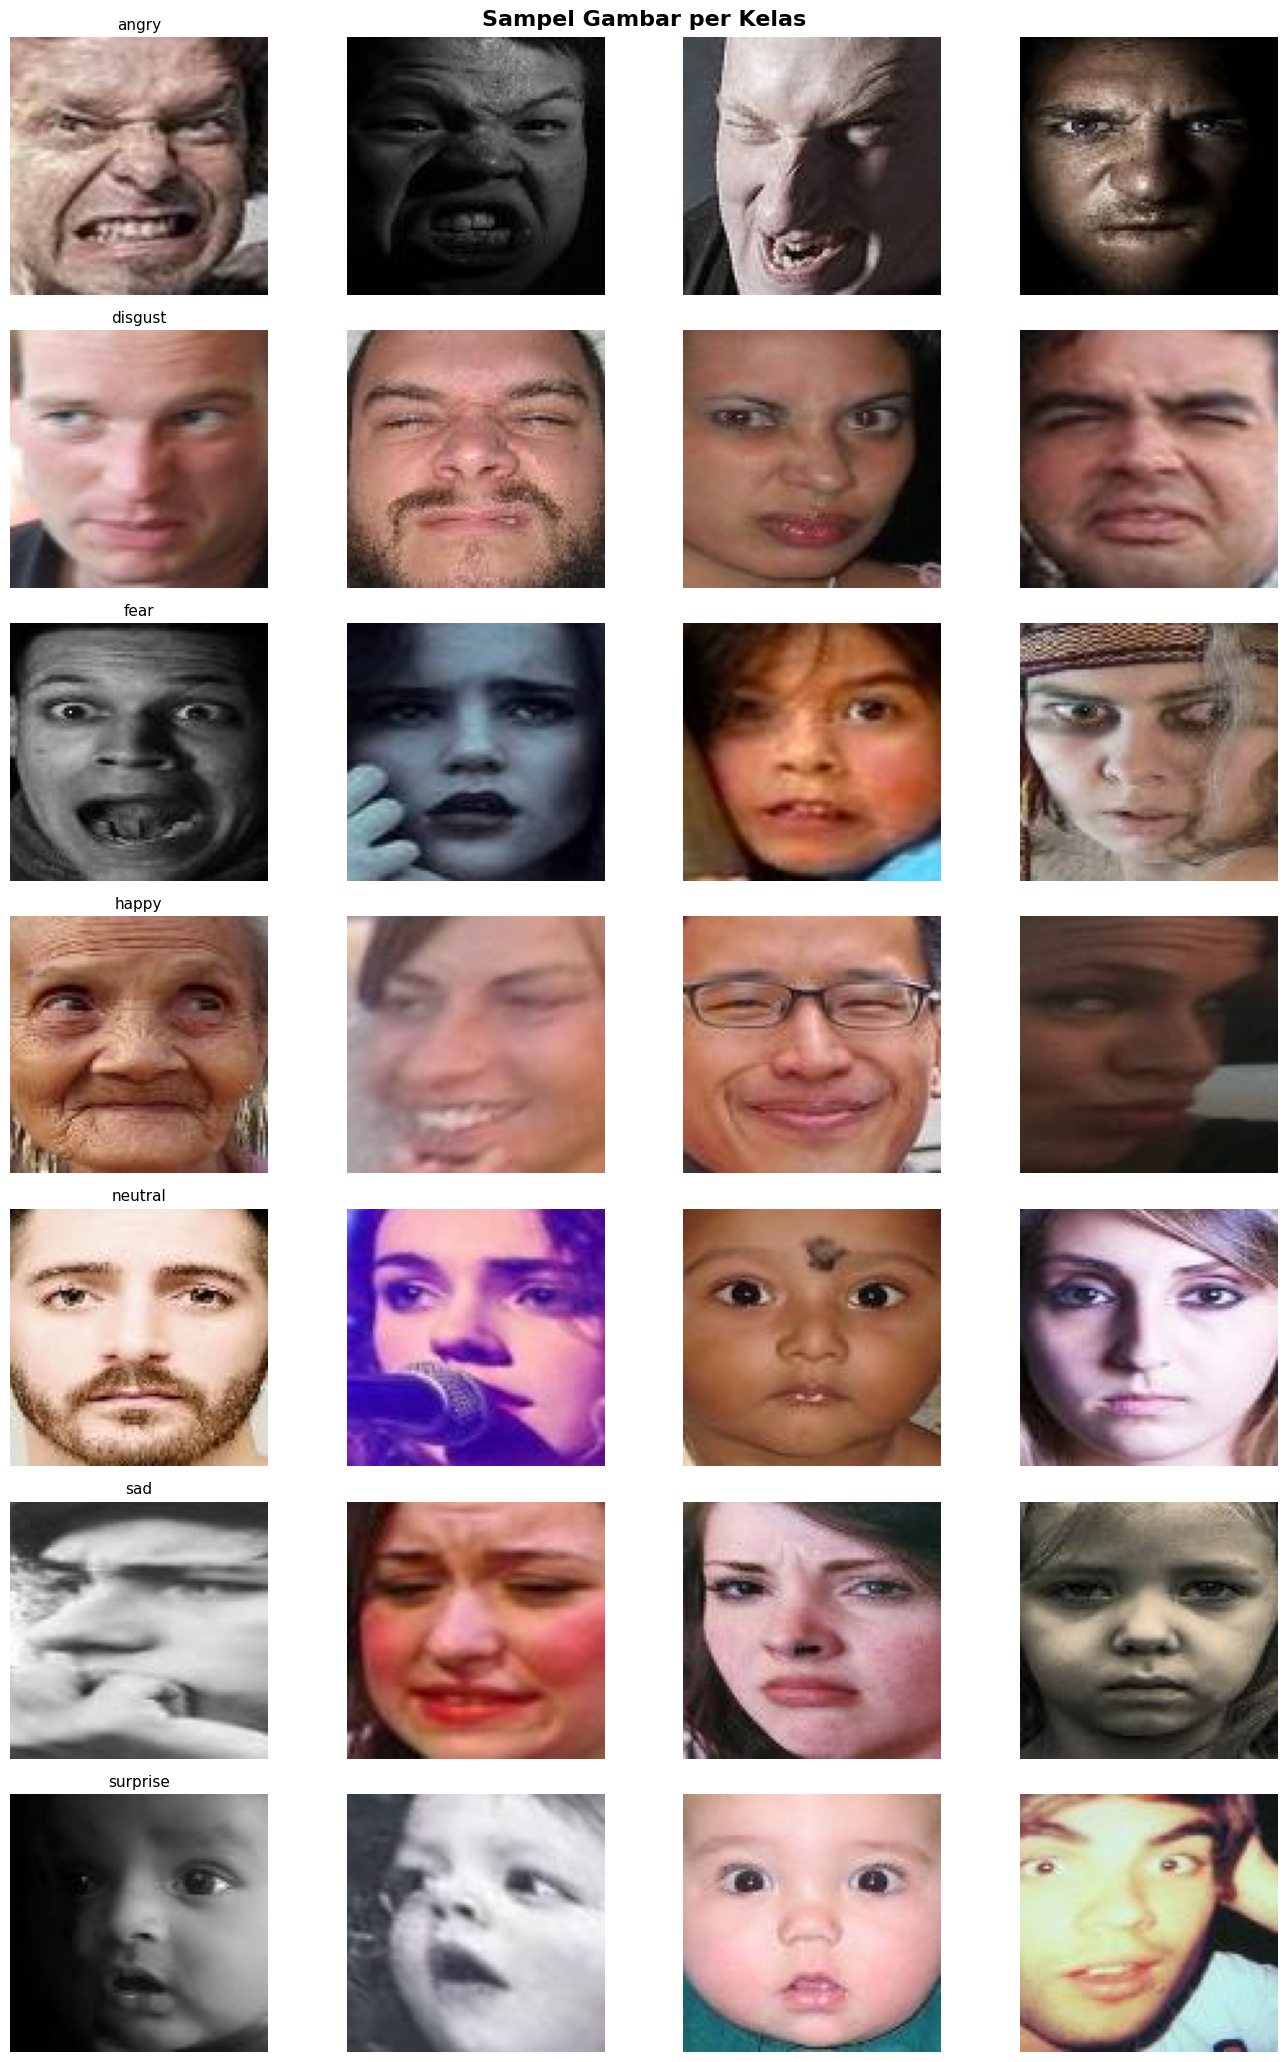

In [6]:
# Tahap 3: Menyiapkan kanvas grid (baris = jumlah kelas, kolom = 4 sampel)
if os.path.exists(TRAIN_DIR) and len(classes) > 0:
    fig, axes = plt.subplots(nrows=len(classes), ncols=4, figsize=(14, len(classes)*3))
    fig.suptitle('Sampel Gambar per Kelas', fontsize=16, fontweight='bold')

    for i, cls in enumerate(classes):
        cls_path = os.path.join(TRAIN_DIR, cls)
        images = os.listdir(cls_path)[:4]  # Ambil 4 gambar pertama sebagai sampel
        for j, img_name in enumerate(images):
            img = mpimg.imread(os.path.join(cls_path, img_name))

            # Tampilkan gambar (gunakan mode grayscale jika gambar 2D)
            axes[i][j].imshow(img, cmap='gray' if len(img.shape) == 2 else None)
            axes[i][j].set_title(cls if j == 0 else '', fontsize=11)
            axes[i][j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Dataset belum di-download/diekstrak ke folder yang tepat.")

## 3. Data Preprocessing (Image Data Generator)

* **Augmentasi**: Diterapkan hanya untuk *training set* guna meningkatkan variasi data dan mencegah *overfitting* (rotasi, *shift*, *zoom*, pembalikan horizontal, *brightness*).
* **Rescaling**: Normalisasi nilai piksel menjadi kisaran 0-1 untuk *train, validation*, dan *test set*.

In [7]:
# 1. Image Data Generator (Augmentasi)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
# 2. Data Generator (Eksekusi Pemuatan)
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    directory=VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 12271 images belonging to 7 classes.
Found 1533 images belonging to 7 classes.
Found 1535 images belonging to 7 classes.


In [9]:
# 3. Informasi Label & Dataset
class_names = list(train_generator.class_indices.keys())
NUM_CLASSES = len(class_names)

print("\nClass Indices       :", train_generator.class_indices)
print("Class Names         :", class_names)
print("Train Samples       :", train_generator.samples)
print("Validation Samples  :", val_generator.samples)
print("Test Samples        :", test_generator.samples)


Class Indices       : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Class Names         : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train Samples       : 12271
Validation Samples  : 1533
Test Samples        : 1535


## 4. Modelling

Model dibangun menggunakan **Sequential CNN** sesuai kriteria, dengan arsitektur:
* **4 blok Feature Extraction**: `Conv2D` → `BatchNormalization` → `MaxPooling2D`
* Filter bertahap: 32 → 64 → 128 → 256
* **Classifier head**: `GlobalAveragePooling2D` (lebih tahan *overfitting* dari `Flatten`) → `Dense(512)` → `Dropout(0.4)` → `Dense(256)` → `Dropout(0.3)` → `Softmax`
* **Regularization**: Ditambahkan L2 Regularizer pada Dense layer.

In [10]:
model = Sequential([
    # Block 1 — 32 filters (Mendeteksi tepi dasar)
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2 — 64 filters (Mendeteksi kurva)
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3 — 128 filters (Mulai merangkai fitur kompleks)
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 4 — 256 filters (Mengenali pola utuh)
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classifier — GlobalAveragePooling lebih tahan overfitting dari Flatten
    GlobalAveragePooling2D(),

    # Fully Connected Layers
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    # Output Layer
    Dense(NUM_CLASSES, activation='softmax')
], name='FaceEmotionCNN')

# Menampilkan rangkuman arsitektur dan jumlah parameternya
model.summary()

Model: "FaceEmotionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,047 (2.50 MB)

 Trainable params: 654,087 (2.50 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Training Model

* **Optimizer**: Adam (Learning Rate 1e-3)
* **Loss**: Categorical Crossentropy
* **Callbacks**:
    * `EarlyStopping` (Patience 10)
    * `ReduceLROnPlateau` (Patience 4, Factor 0.5)
    * `ModelCheckpoint` (Menyimpan bobot terbaik)

In [11]:
# 1. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_face_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 3. Fitting
print("Memulai proses training untuk model Face Emotion...")
history = model.fit(
    train_generator,
    epochs=50, # Sesuaikan jumlah epoch sesuai kebutuhan (bisa diubah ke 50)
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Memulai proses training untuk model Face Emotion...
Epoch 1/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.3595 - loss: 1.7988
Epoch 1: val_accuracy improved from None to 0.38878, saving model to best_face_emotion_model.keras

Epoch 1: finished saving model to best_face_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 201s 489ms/step - accuracy: 0.3782 - loss: 1.7384 - val_accuracy: 0.3888 - val_loss: 1.7005 - learning_rate: 0.0010
Epoch 2/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.3941 - loss: 1.6767
Epoch 2: val_accuracy improved from 0.38878 to 0.39987, saving model to best_face_emotion_model.keras

Epoch 2: finished saving model to best_face_emotion_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 175s 457ms/step - accuracy: 0.3934 - loss: 1.6719 - val_accuracy: 0.3999 - val_loss: 1.6243 - learning_rate: 0.0010
Epoch 3/50
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.3979 - loss: 1.6601
Epoch 3: val_accuracy improved from 0.39987 to 0.40183, saving 

## 6. Evaluasi dan Visualisasi

Memvisualisasikan *Learning Curve* (Akurasi dan Loss), mengevaluasi performa akhir menggunakan Test Set, dan mencetak *Confusion Matrix* serta *Classification Report*.

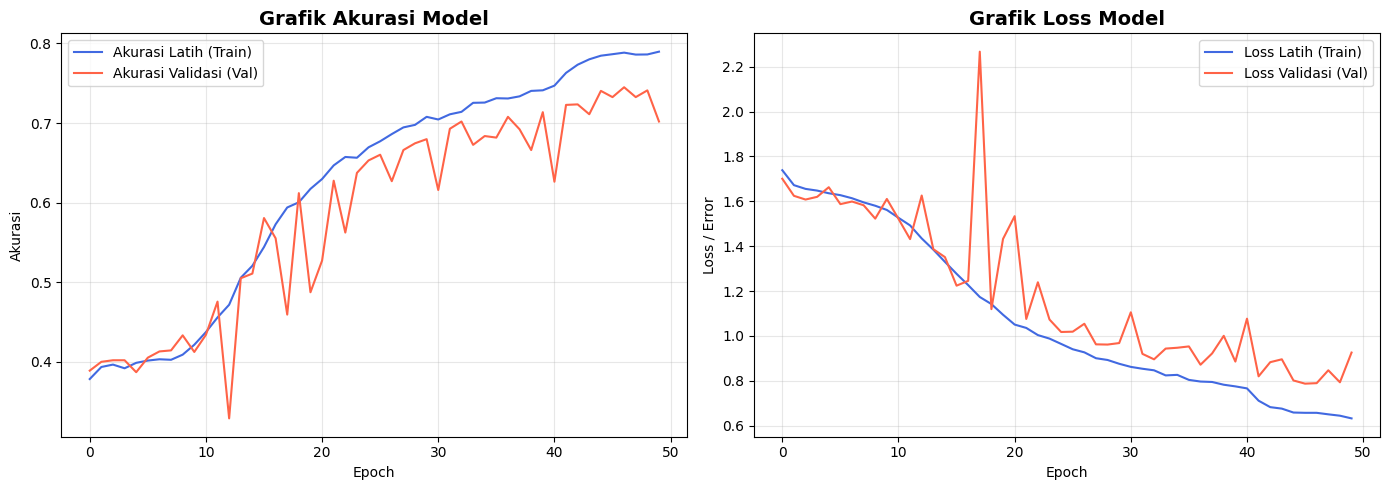

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. Grafik Training & Validation
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Akurasi
axes[0].plot(history.history['accuracy'], label='Akurasi Latih (Train)', color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Akurasi Validasi (Val)', color='tomato')
axes[0].set_title('Grafik Akurasi Model', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Loss Latih (Train)', color='royalblue')
axes[1].plot(history.history['val_loss'], label='Loss Validasi (Val)', color='tomato')
axes[1].set_title('Grafik Loss Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss / Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_face_emotion.png', dpi=150, bbox_inches='tight')
plt.show()



In [13]:
# ==========================================
# 2. Evaluasi pada Test Set
# ==========================================
print('=' * 50)
print('EVALUASI MODEL PADA DATA UJI (TEST SET)')
print('=' * 50)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print('-' * 50)
print(f'➤ Test Loss     : {test_loss:.4f}')
print(f'➤ Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

if 'history' in globals():
    train_acc_final = max(history.history['accuracy'])
    print(f'➤ Best Train Acc: {train_acc_final:.4f} ({train_acc_final*100:.2f}%)')
    selisih = (train_acc_final - test_acc) * 100
    print(f'➤ Kesenjangan   : {selisih:.2f}% (Semakin kecil semakin baik)')
print('-' * 50)



EVALUASI MODEL PADA DATA UJI (TEST SET)
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7329 - loss: 0.8082
--------------------------------------------------
➤ Test Loss     : 0.8082
➤ Test Accuracy : 0.7329 (73.29%)
➤ Best Train Acc: 0.7897 (78.97%)
➤ Kesenjangan   : 5.68% (Semakin kecil semakin baik)
--------------------------------------------------


48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step


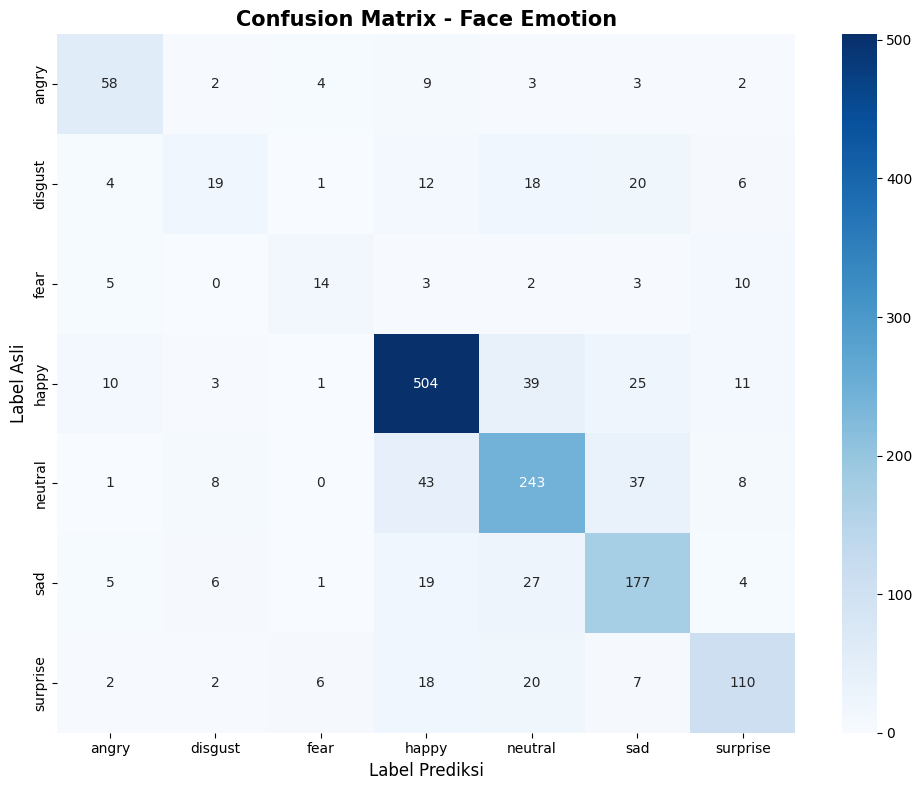


CLASSIFICATION REPORT - FACE EMOTION
              precision    recall  f1-score   support

       angry       0.68      0.72      0.70        81
     disgust       0.47      0.24      0.32        80
        fear       0.52      0.38      0.44        37
       happy       0.83      0.85      0.84       593
     neutral       0.69      0.71      0.70       340
         sad       0.65      0.74      0.69       239
    surprise       0.73      0.67      0.70       165

    accuracy                           0.73      1535
   macro avg       0.65      0.61      0.63      1535
weighted avg       0.73      0.73      0.73      1535



In [14]:
# ==========================================
# 3. Prediksi & Confusion Matrix
# ==========================================
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Face Emotion', fontsize=15, fontweight='bold')
plt.ylabel('Label Asli', fontsize=12)
plt.xlabel('Label Prediksi', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_face_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print('\n' + '=' * 60)
print('CLASSIFICATION REPORT - FACE EMOTION')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

## 7. Konversi Model

Model akan disimpan ke dalam 3 format *deployment*:
1.  **SavedModel** — Deployment server/cloud.
2.  **TF-Lite** — Deployment *mobile & embedded* (Android/iOS).
3.  **TFJS** — Deployment browser (JavaScript).

In [15]:
os.makedirs('hasil_model/saved_model', exist_ok=True)
os.makedirs('hasil_model/tflite',      exist_ok=True)
os.makedirs('hasil_model/tfjs_model',  exist_ok=True)

# 1. Ekspor ke Format SavedModel
saved_model_path = 'hasil_model/saved_model'
print("Memulai proses ekspor model...\n")
try:
    model.export(saved_model_path)
    print('✅ SavedModel disimpan via model.export()')
except Exception:
    try:
        model.save(saved_model_path, save_format='tf')
        print('✅ SavedModel disimpan via model.save()')
    except Exception:
        tf.keras.saving.save_model(model, saved_model_path, save_format='tf')
        print('✅ SavedModel disimpan via tf.keras.saving')

# 2. Ekspor ke Format TensorFlow Lite (TFLite)
tflite_path = 'hasil_model/tflite/face_emotion_model.tflite'
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'✅ Model TFLite disimpan di: {tflite_path}')

# 3. Ekspor ke Format TensorFlow.js (TFJS)
!pip install -q tensorflowjs
tfjs_path = 'hasil_model/tfjs_model'

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    {saved_model_path} \
    {tfjs_path}
print(f'✅ Model TFJS disimpan di: {tfjs_path}')

# 4. Zip Folder Hasil Model
!zip -r hasil_model.zip hasil_model/

# 5. Download Otomatis
from google.colab import files
files.download('hasil_model.zip')
print('\n⬇️ hasil_model.zip siap didownload!')

Memulai proses ekspor model...

Saved artifact at 'hasil_model/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  132883288033232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288034000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288035920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288036304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288032848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288035536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288035344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288036688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288037072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132883288037264: TensorSpec(shape=(), dtype=t

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️ hasil_model.zip siap didownload!


## 8. Inference (Optional)

Uji coba prediksi menggunakan model yang sudah dilatih pada satu sampel gambar dan pada galeri acak dari Test Set.

Mencoba prediksi pada gambar: test_1720_aligned.jpg (Label Asli: sad)


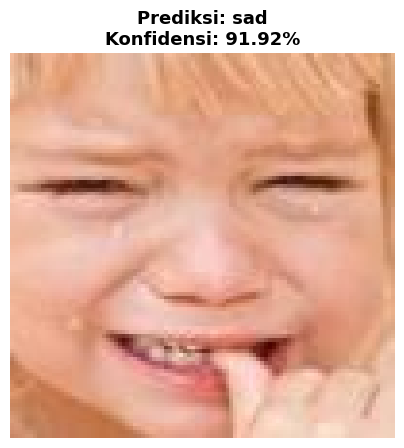

----------------------------------------
Probabilitas per Kelas:
----------------------------------------
  angry            0.01% 
  disgust          0.03% 
  fear             0.04% 
  happy            7.99% ██
  neutral          0.01% 
  sad             91.92% ███████████████████████████
  surprise         0.00% 
----------------------------------------


In [21]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Gunakan modul utils bawaan TF yang lebih modern dan aman dari error
from tensorflow.keras.utils import load_img, img_to_array

# ==========================================
# Fungsi Uji Coba Prediksi Gambar Tunggal
# ==========================================
def predict_image(img_path, model, class_names, img_size=(224, 224)):
    # 1. Persiapan Gambar
    img       = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Prediksi
    preds      = model.predict(img_array, verbose=0)
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    # 3. Tampilan Visual Gambar
    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(img_path))
    plt.title(f'Prediksi: {pred_class}\nKonfidensi: {confidence:.2f}%', fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.show()

    # 4. Cetak Probabilitas per Kelas
    print('-' * 40)
    print('Probabilitas per Kelas:')
    print('-' * 40)
    for cls, prob in zip(class_names, preds[0]):
        bar = '█' * int(prob * 30)
        print(f'  {cls:<15} {prob*100:5.2f}% {bar}')
    print('-' * 40)

    return pred_class, confidence

# ==========================================
# Eksekusi Uji Coba pada Sample Data Test
# ==========================================

# Memilih nama kelas secara acak menggunakan random.choice()
sample_class = random.choice(class_names)
sample_dir   = os.path.join(TEST_DIR, sample_class)

# Memilih file gambar secara acak dari dalam folder kelas tersebut
sample_file  = random.choice(os.listdir(sample_dir))
sample_img   = os.path.join(sample_dir, sample_file)

# Menampilkan informasi gambar dan menjalankan fungsi prediksi
print(f"Mencoba prediksi pada gambar: {sample_file} (Label Asli: {sample_class})")
pred_class, conf = predict_image(sample_img, model, class_names, img_size=IMG_SIZE)

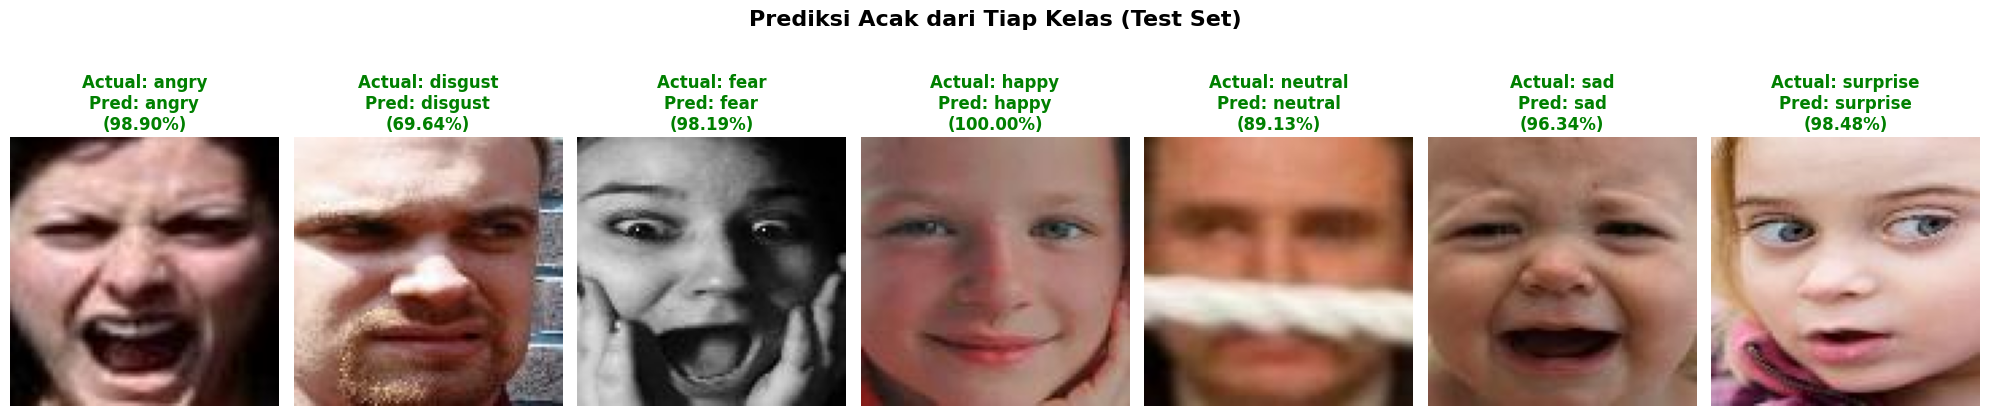

In [40]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# ==========================================
# Galeri Prediksi Acak (Test Set)
# ==========================================

# Menyiapkan kanvas memanjang ke samping (kolom sebanyak jumlah kelas)
fig, axes = plt.subplots(1, len(class_names), figsize=(20, 5))
fig.suptitle('Prediksi Acak dari Tiap Kelas (Test Set)', fontsize=16, fontweight='bold')

for i, cls in enumerate(class_names):
    # 1. Ambil 1 gambar acak dari tiap kelas
    cls_test_path   = os.path.join(TEST_DIR, cls)
    random_img_name = random.choice(os.listdir(cls_test_path))
    img_path        = os.path.join(cls_test_path, random_img_name)

    # 2. Preprocessing (Menggunakan load_img dan img_to_array yang baru)
    img       = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Prediksi
    preds      = model.predict(img_array, verbose=0)
    pred_idx   = np.argmax(preds)
    pred_class = class_names[pred_idx]
    confidence = np.max(preds) * 100

    # 4. Visualisasi & Logika Warna
    axes[i].imshow(load_img(img_path))

    # Hijau jika benar, Merah jika salah tebak
    color = 'green' if pred_class == cls else 'red'

    axes[i].set_title(
        f'Actual: {cls}\nPred: {pred_class}\n({confidence:.2f}%)',
        color=color,
        fontsize=12,
        fontweight='bold'
    )
    axes[i].axis('off')

# Merapikan jarak antar gambar
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()